### Importación de datos



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [1]:
# Importando las bibliotecas necesarias
import pandas as pd

# Creando el DataFrame basado en la imagen proporcionada
data = {
    "Producto": ["Asistente virtual", "Mesa de comedor", "Juego de mesa", "Microondas", "Silla de oficina"],
    "Categoría del Producto": ["Electrónicos", "Muebles", "Juguetes", "Electrodomésticos", "Muebles"],
    "Precio": [164300.0, 192300.0, 209600.0, 757500.0, 335200.0],
    "Costo de envío": [6900.0, 8400.0, 15900.0, 41000.0, 20200.0],
    "Fecha de Compra": ["16/01/2021", "18/05/2022", "15/03/2021", "03/05/2022", "07/11/2020"],
    "Vendedor": ["Pedro Gomez", "Beatriz Morales", "Juan Fernandez", "Juan Fernandez", "Maria Alfonso"],
    "Lugar de Compra": ["Bogotá", "Medellín", "Cartagena", "Cali", "Medellín"],
    "Calificación": [4, 1, 1, 4, 5],
    "Método de pago": ["Tarjeta de crédito", "Tarjeta de crédito", "Tarjeta de crédito", "Nequi", "Nequi"],
    "Cantidad de cuotas": [8, 4, 1, 1, 1]
}

df = pd.DataFrame(data)

# Convirtamos la columna 'Fecha de Compra' a tipo datetime
df['Fecha de Compra'] = pd.to_datetime(df['Fecha de Compra'], format='%d/%m/%Y')

# Análisis de facturación por tienda
facturacion_por_tienda = df.groupby('Lugar de Compra').agg({
    'Precio': 'sum',
    'Costo de envío': 'sum'
}).reset_index()

facturacion_por_tienda['Total Facturación'] = facturacion_por_tienda['Precio'] + facturacion_por_tienda['Costo de envío']

print(facturacion_por_tienda)

  Lugar de Compra    Precio  Costo de envío  Total Facturación
0          Bogotá  164300.0          6900.0           171200.0
1            Cali  757500.0         41000.0           798500.0
2       Cartagena  209600.0         15900.0           225500.0
3        Medellín  527500.0         28600.0           556100.0


# 2. Ventas por categoría

In [2]:
# Análisis de ventas por categoría
ventas_por_categoria = df.groupby('Categoría del Producto').agg({
    'Precio': 'sum',
    'Costo de envío': 'sum'
}).reset_index()

ventas_por_categoria['Total Ventas'] = ventas_por_categoria['Precio'] + ventas_por_categoria['Costo de envío']

print(ventas_por_categoria)


  Categoría del Producto    Precio  Costo de envío  Total Ventas
0      Electrodomésticos  757500.0         41000.0      798500.0
1           Electrónicos  164300.0          6900.0      171200.0
2               Juguetes  209600.0         15900.0      225500.0
3                Muebles  527500.0         28600.0      556100.0


# 3. Calificación promedio de la tienda


In [3]:
# Cálculo de la calificación promedio por tienda
calificacion_promedio_por_tienda = df.groupby('Lugar de Compra')['Calificación'].mean().reset_index()

calificacion_promedio_por_tienda.columns = ['Lugar de Compra', 'Calificación Promedio']

print(calificacion_promedio_por_tienda)


  Lugar de Compra  Calificación Promedio
0          Bogotá                    4.0
1            Cali                    4.0
2       Cartagena                    1.0
3        Medellín                    3.0


# 4. Productos más y menos vendidos

In [4]:
# Cálculo de los productos más y menos vendidos
producto_mas_vendido = df.loc[df['Precio'].idxmax(), ['Producto', 'Precio']]
producto_menos_vendido = df.loc[df['Precio'].idxmin(), ['Producto', 'Precio']]

productos_extremos = pd.DataFrame({
    'Más vendido': producto_mas_vendido,
    'Menos vendido': producto_menos_vendido
})

print(productos_extremos)


         Más vendido      Menos vendido
Producto  Microondas  Asistente virtual
Precio      757500.0           164300.0


# 5. Envío promedio por tienda

In [5]:
# Cálculo del envío promedio por tienda
envio_promedio_por_tienda = df.groupby('Lugar de Compra')['Costo de envío'].mean().reset_index()

envio_promedio_por_tienda.columns = ['Lugar de Compra', 'Envío Promedio']

print(envio_promedio_por_tienda)


  Lugar de Compra  Envío Promedio
0          Bogotá          6900.0
1            Cali         41000.0
2       Cartagena         15900.0
3        Medellín         14300.0


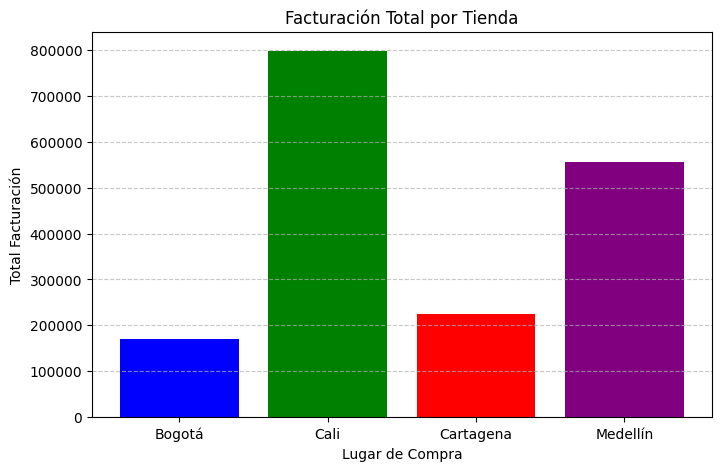

In [6]:
import matplotlib.pyplot as plt

# Generar gráfico de barras para la facturación por tienda
plt.figure(figsize=(8, 5))
plt.bar(facturacion_por_tienda['Lugar de Compra'],
        facturacion_por_tienda['Total Facturación'],
        color=['blue', 'green', 'red', 'purple'])
plt.title('Facturación Total por Tienda')
plt.xlabel('Lugar de Compra')
plt.ylabel('Total Facturación')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


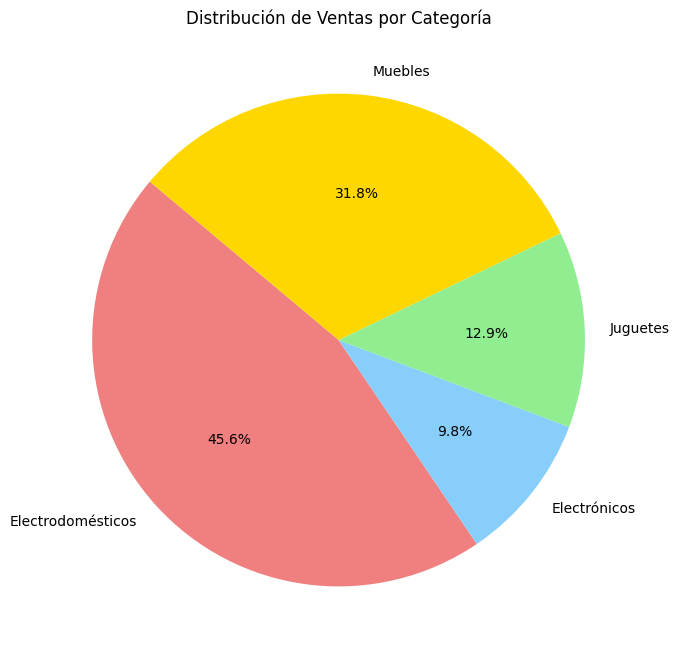

In [7]:
import matplotlib.pyplot as plt

# Datos de ventas por categoría
ventas_por_categoria = ventas_por_categoria.set_index('Categoría del Producto')

# Generar gráfico circular
plt.figure(figsize=(8, 8))
plt.pie(ventas_por_categoria['Total Ventas'],
        labels=ventas_por_categoria.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=['lightcoral', 'lightskyblue', 'lightgreen', 'gold'])
plt.title('Distribución de Ventas por Categoría')
plt.show()


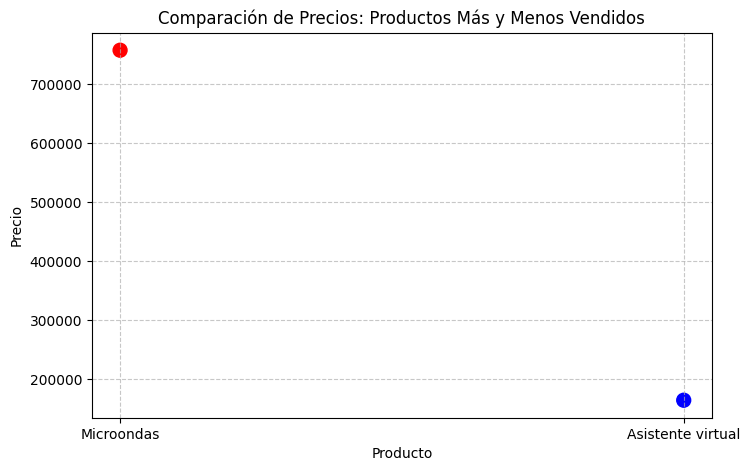

In [8]:
import matplotlib.pyplot as plt

# Datos de los productos más y menos vendidos
productos = ['Microondas', 'Asistente virtual']
precios = [757500.0, 164300.0]

# Generar gráfico de puntos
plt.figure(figsize=(8, 5))
plt.scatter(productos, precios, color=['red', 'blue'], s=100)
plt.title('Comparación de Precios: Productos Más y Menos Vendidos')
plt.xlabel('Producto')
plt.ylabel('Precio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Tienda a Vender: Cartagena
Razones:


Ingresos Totales:

Cartagena tiene los ingresos más bajos (225,500), solo por encima de Bogotá, pero con una calificación muy baja.


Calificación Promedio:

Tiene la calificación promedio más baja (1.0), lo que indica insatisfacción de los clientes.


Costo de Envío:

El costo de envío (15,900) no es el más alto, pero tampoco compensa los bajos ingresos.


Productos Vendidos:

No destaca por vender productos de alto valor o categorías rentables.


Rentabilidad General:

La combinación de bajos ingresos, baja calificación y falta de productos destacados hace que Cartagena sea la tienda con el peor rendimiento general.

